In [1]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(BuenColors)
library(Signac)
library(EnsDb.Mmusculus.v79)
library(GenomeInfoDb)
library(clusterProfiler)
library(org.Mm.eg.db)
library(ggrepel)
library(ggrastr)
library(future)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: MASS


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select


Loading required package: ensembldb

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘pa

In [2]:
# Set up multithreading for faster processing
plan('multicore', workers = 16)

In [3]:
gene_annotations <- GetGRangesFromEnsDb(ensdb = EnsDb.Mmusculus.v79)
seqlevels(gene_annotations) <- paste0('chr', seqlevels(gene_annotations))
seqlevels(gene_annotations)[seqlevels(gene_annotations) == 'chrMT'] <- 'chrM'
gene_annotations <- keepStandardChromosomes(gene_annotations, pruning.mode = 'coarse')
genome(gene_annotations) <- 'mm10'

Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warn

In [4]:
setwd('/gpfs/commons/groups/vickovic_lab/rhe/projects/005/space_tag_reproducibility/fig2')

#### Figures 2f and 2h: Differential expression volcano plots with overlap to genes near differential peaks

In [5]:
merged_obj <- readRDS('processed_data/aging_brain_hex_obj_merged_tiled_processed_requant.rds')

In [6]:
DefaultAssay(merged_obj) <- 'RNA_Spatial'
ages_groups_test <- c('12m', '18m', '24m')
diff_peaks_dir <- 'processed_data/differential_peaks'

In [7]:
get_de_results <- function(merged_obj, annotation_use) {
  subset_obj <- subset(merged_obj, subset = annotation_assigned == gsub('_', ' ', annotation_use))
  de_results_list <- list()

  for (age_group in ages_groups_test) {
    de_results <- FindMarkers(
      subset_obj,
      ident.1 = age_group,
      ident.2 = '3m',
      group.by = 'age',
      logfc.threshold = 0,
      min.pct = 0.1,
      test.use = 'wilcox'
    )
    de_results_list[[age_group]] <- de_results
  }

  de_results_list[['24m']]
}

In [8]:
get_associated_genes <- function(annotation_use, diff_peaks_dir, gene_annotations) {
  files <- list.files(
    file.path(diff_peaks_dir, annotation_use),
    pattern = '_DE_peaks.bed$',
    full.names = TRUE
  )

  peaks_list <- list()
  for (file in files) {
    peaks_list[[file]] <- StringToGRanges(rownames(read.table(file, header = TRUE)))
  }

  all_peaks <- Reduce(c, peaks_list)
  dist_to_gene <- distanceToNearest(all_peaks, gene_annotations)
  all_peaks$nearest_gene <- gene_annotations$gene_name[subjectHits(dist_to_gene)]
  all_peaks$nearest_gene_distance <- mcols(dist_to_gene)$distance

  unique(all_peaks[all_peaks$nearest_gene_distance <= 10000]$nearest_gene)
}

In [9]:
make_volcano_plot <- function(plot_df, associated_genes, genes_label, plot_title) {
  plot_df2 <- plot_df %>%
    mutate(
      significant = ifelse(is.na(p_val_adj), FALSE, abs(avg_log2FC) >= 0.5 & p_val_adj <= 0.05),
      sig_dir = case_when(
        significant & avg_log2FC > 0 ~ 'Up',
        significant & avg_log2FC < 0 ~ 'Down',
        TRUE ~ 'Insig'
      ),
      color = case_when(
        sig_dir == 'Up' ~ 'darkred',
        sig_dir == 'Down' ~ 'darkblue',
        TRUE ~ 'grey70'
      ),
      alpha = ifelse(rownames(.) %in% associated_genes, 1, 0.2),
      size = ifelse(rownames(.) %in% associated_genes, 1.5, 1)
    )

  plot_df2$gene <- rownames(plot_df2)

  ggplot(plot_df2, aes(x = avg_log2FC, y = -log10(p_val_adj))) +
    ggrastr::rasterise(geom_point(aes(color = color, alpha = alpha, size = size)), dpi = 300) +
    geom_point(
      data = subset(plot_df2, gene %in% genes_label),
      shape = 21,
      color = 'black',
      fill = NA,
      size = 3,
      stroke = 1,
      show.legend = FALSE
    ) +
    geom_vline(xintercept = 0, linetype = 'dashed', color = 'black') +
    geom_vline(xintercept = c(-0.5, 0.5), linetype = 'dashed', color = 'black', linewidth = 1) +
    geom_hline(yintercept = -log10(0.05), linetype = 'dashed', color = 'black', linewidth = 1) +
    ggrepel::geom_text_repel(
      data = subset(plot_df2, gene %in% genes_label),
      aes(label = gene),
      size = 5,
      max.overlaps = 20
    ) +
    scale_color_identity() +
    scale_alpha_identity() +
    scale_size_identity() +
    theme_classic() +
    coord_cartesian(xlim = c(-5, 5)) +
    labs(
      x = expression(log[2] * '-fold-change'),
      y = expression(-log[10] * 'p-value'[adj]),
      title = plot_title
    )
}

##### Figure 2f: Differential Expression 24m vs. 3m in fiber tracts

Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>."
Warning message in .merge_two_Seqinfo_objects(x, y):
"Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chr1, chr6, chr10, chr13, chr17, chrY, chr3, chr4, chr7, chr9, chr12, chr14, chr15, chr16, chr18
  - in 'y': chrX
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning)."


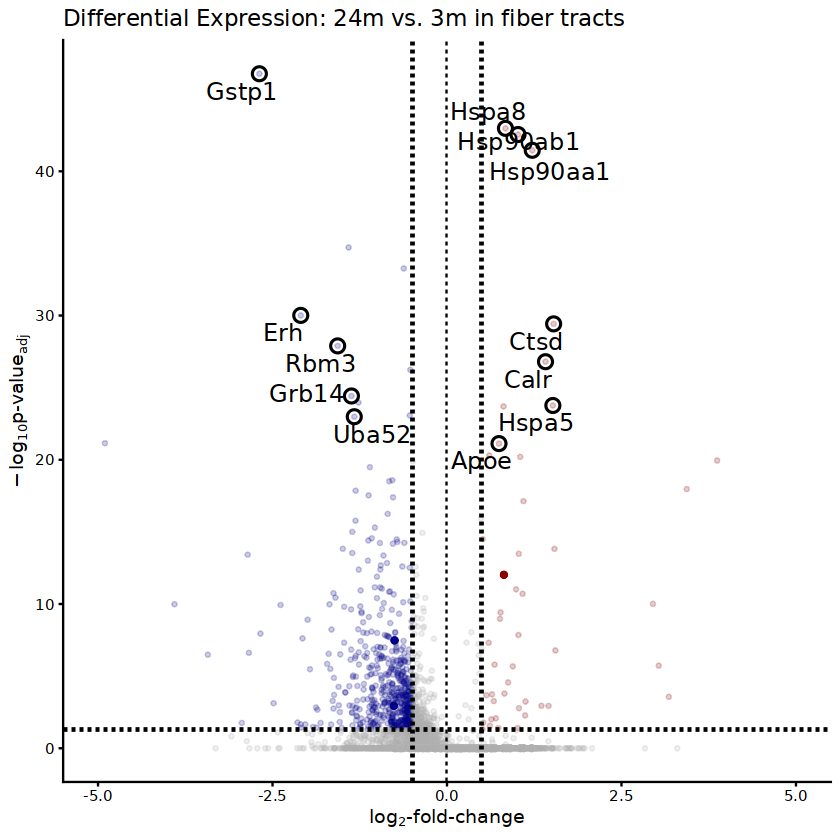

In [10]:
annotation_use <- 'fiber_tracts'
plot_df <- get_de_results(merged_obj, annotation_use)
associated_genes <- get_associated_genes(annotation_use, diff_peaks_dir, gene_annotations)
genes_label <- c('Gstp1', 'Grb14', 'Uba52', 'Rbm3', 'Erh', 'Hspa8', 'Hsp90aa1', 'Hsp90ab1', 'Hspa5', 'Calr', 'Ctsd', 'Apoe')

p <- make_volcano_plot(
  plot_df,
  associated_genes,
  genes_label,
  'Differential Expression: 24m vs. 3m in fiber tracts'
)
print(p)

##### Figure 2h: Differential Expression 24m vs. 3m in isocortex

Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message:
"Not validating Seurat objects"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrY
  - in 'y': chr1, chr3, chr8, chr10, chr14
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning)."
Warning message in .merge_two_Seqinfo_objects(x, y):
"Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrY
  - in 'y': chr2, chr4, chr5, chr6, chr7, chr9, chr12, chr13, chr15, chr17, chr18, chr19
  Make sure to always combine/compare objects based on the same reference
  genome (use sup

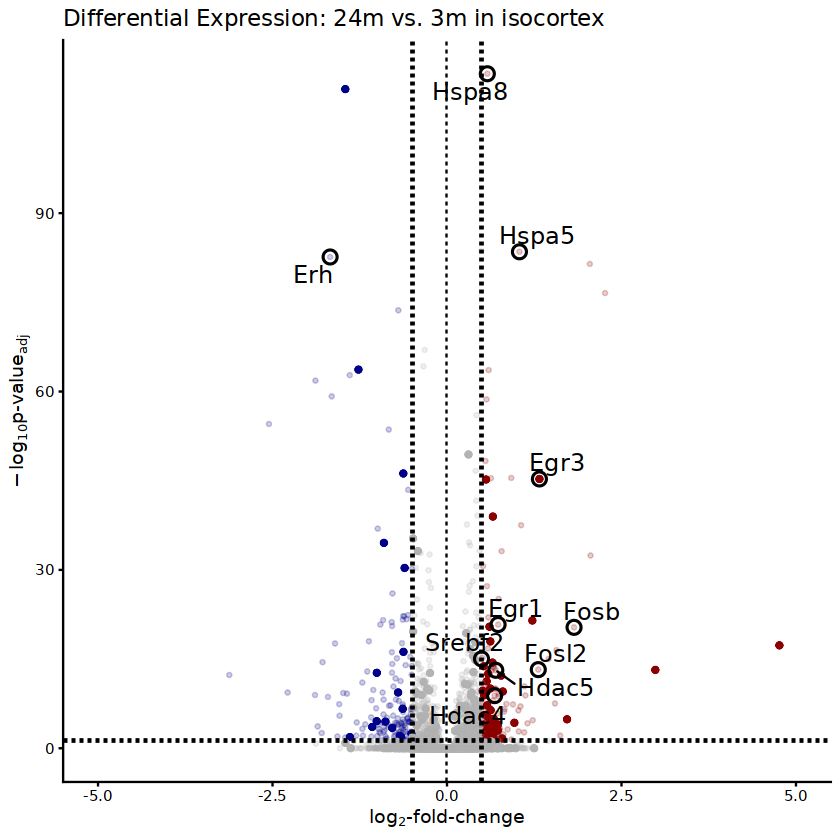

In [11]:
annotation_use <- 'isocortex'
plot_df <- get_de_results(merged_obj, annotation_use)
associated_genes <- get_associated_genes(annotation_use, diff_peaks_dir, gene_annotations)

genes_label <- c('Erh','Hspa8','Hspa5','Egr3','Egr1','Fosb','Srebf2','Fosl2','Hdac5','Hdac4')

p <- make_volcano_plot(
  plot_df,
  associated_genes,
  genes_label,
  'Differential Expression: 24m vs. 3m in isocortex'
)
print(p)